In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import os
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

# Train a simple CNN to learn a good image feature map 

In [2]:
class CustomCNN(nn.Module):
    def __init__(self, in_channels=1, conv1_out_channels=32, conv2_out_channels=64, fc1_units=128, fc2_units=10):
        super(CustomCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, conv1_out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(conv1_out_channels, conv2_out_channels, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(conv2_out_channels * 7 * 7, fc1_units)
        self.fc2 = nn.Linear(fc1_units, fc2_units)
        self.relu = nn.ReLU()

    def forward(self, x, return_features=False):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        features = x.view(x.size(0), -1)
        x = self.relu(self.fc1(features))
        outputs = self.fc2(x)
        if return_features:
            return outputs, features
        else:
            return outputs


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters and Model Params
input_channels = 1  # MNIST has grayscale images
conv1_out_channels = 16
conv2_out_channels = 16
fc1_units = 128
fc2_units = 10  # 10 classes for MNIST digits

# Initialize the model
model = CustomCNN(input_channels, conv1_out_channels, conv2_out_channels, fc1_units, fc2_units).to(device)

# Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


### Load MNIST

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # Normalizing with mean and std deviation of MNIST dataset
])

# Check if MNIST dataset exists locally
data_path = './data'
trainset = torchvision.datasets.MNIST(root=data_path, train=True, download=not os.path.exists(data_path), transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.MNIST(root=data_path, train=False, download=not os.path.exists(data_path), transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=1000, shuffle=False)


### Train the Model

In [5]:
# Training Parameters
max_epochs = 100
accuracy_threshold = 98.0

def evaluate_accuracy(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in dataloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    model.train()
    return accuracy

In [6]:
# Training Code
num_epochs = 1000
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(num_epochs):
    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch + 1}, Loss: {running_loss / len(trainloader)}")
    
    # Check accuracy on test set and stop training if accuracy >= 98%
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    print(f"Accuracy on test set: {accuracy}%")
    if accuracy >= 98:
        print("Reached 98% accuracy, stopping training.")
        break


Epoch 1, Loss: 0.21272646889650523
Accuracy on test set: 98.0%
Reached 98% accuracy, stopping training.


In [7]:
# Feature Extraction Code
model.eval()  # Set model to evaluation mode

features_list = []
labels_list = []

with torch.no_grad():
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        outputs, features = model(images, return_features=True)  # Extract features
        features_list.append(features.cpu().numpy())
        labels_list.append(labels.cpu().numpy())

# Convert lists to numpy arrays
features_array = np.concatenate(features_list, axis=0)
labels_array = np.concatenate(labels_list, axis=0)


# Isolate to just MNIST images of 0s and 1s

In [8]:
filter_indices = np.where((labels_array == 0) | (labels_array == 1))[0]
filtered_features_array = features_array[filter_indices]
filtered_labels_array = labels_array[filter_indices]

In [9]:
filtered_labels_array.shape, filtered_features_array.shape

((12665,), (12665, 784))

# Train multilayer Swinhart Abbott Model on classification

In [10]:
class FilteredMNIST(Dataset):
    def __init__(self, root, train=True, transform=None, download=True):
        self.mnist = torchvision.datasets.MNIST(root=root, train=train, transform=transform, download=download)
        self.data = [(img, label) for img, label in zip(self.mnist.data, self.mnist.targets) if label in [0, 1]]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, label = self.data[idx]
        if self.mnist.transform:
            img = self.mnist.transform(img)
        return img, label

# Define transformation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Create filtered dataset and dataloader
trainset = FilteredMNIST(root='./data', train=True, transform=transform, download=True)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)

testset = FilteredMNIST(root='./data', train=False, transform=transform, download=True)
testloader = DataLoader(testset, batch_size=1000, shuffle=False)

In [11]:
class SwinehartAbbottNetworkMultiLayer_ALT(nn.Module):
    def __init__(self, L1_size, L2_size, L3_size, init_gain, init_shift, alpha, connect_prob=0.9, manual_gains_shifts=None, manual_weights=None):
        super(SwinehartAbbottNetworkMultiLayer_ALT, self).__init__()

        torch.manual_seed(0)

        weight_mag = 1
        
        self.L1_size = L1_size

        if manual_gains_shifts is None:
            self.L1_gains = nn.Parameter(torch.full((L1_size, 1), init_gain, dtype=torch.float32))
            self.L1_shifts = nn.Parameter(torch.full((L1_size, 1), init_shift, dtype=torch.float32))
            #self.L1_gains = nn.Parameter(init_gain*torch.empty(L1_size, 1).uniform_(-1, 1))
            #self.L1_shifts = nn.Parameter(init_shift*torch.empty(L1_size, 1).uniform_(-1, 1))
        else:
            self.L1_gains = torch.from_numpy(manual_gains_shifts['L1_gains']).float()
            self.L1_shifts = torch.from_numpy(manual_gains_shifts['L1_shifts']).float()

            self.L1_gains = nn.Parameter(self.L1_gains)
            self.L1_shifts = nn.Parameter(self.L1_shifts)



        init_L1_weight = (1 / L1_size) * int(L1_size * alpha)
        self.alpha = alpha
        if manual_weights is None:
            #init_L1_weights = torch.rand((L2_size, L1_size), dtype=torch.float32)
            #init_L1_weights /= init_L1_weights.sum(dim=1, keepdim=True)
            init_L1_weights = torch.empty(L2_size, L1_size).uniform_(-weight_mag, weight_mag)
            init_L1_weights /= torch.abs(init_L1_weights).sum(dim=1, keepdim=True)

            L1_weights = init_L1_weights * int(L1_size * alpha)
            L1_mask = torch.from_numpy(np.random.choice([1, 0], size=L1_weights.shape, p=[connect_prob, 1 - connect_prob])).float()
        else:
            L1_weights = torch.from_numpy(manual_weights['L1_weights']).float()
            L1_mask = torch.from_numpy(manual_weights['L1_mask']).float()
        
        #self.register_buffer('L1_weights', L1_weights)
        self.L1_weights = nn.Parameter(L1_weights)
        self.register_buffer('L1_mask', L1_mask)

        self.L2_size = L2_size

        if manual_gains_shifts is None:
            self.L2_gains = nn.Parameter(torch.full((L2_size, 1), init_gain, dtype=torch.float32))
            self.L2_shifts = nn.Parameter(torch.full((L2_size, 1), init_shift, dtype=torch.float32))
            #self.L2_gains = nn.Parameter(init_gain*torch.empty(L2_size, 1).uniform_(-1, 1))
            #self.L2_shifts = nn.Parameter(init_shift*torch.empty(L2_size, 1).uniform_(-1, 1))  
        else:
            self.L2_gains = torch.from_numpy(manual_gains_shifts['L2_gains']).float()
            self.L2_shifts = torch.from_numpy(manual_gains_shifts['L2_shifts']).float()            
            self.L2_gains = nn.Parameter(self.L2_gains)
            self.L2_shifts = nn.Parameter(self.L2_shifts)
                
        if manual_weights is None:
            #init_L2_weights = torch.rand((L3_size, L2_size), dtype=torch.float32)
            #init_L2_weights /= init_L2_weights.sum(dim=1, keepdim=True)
            init_L2_weights = torch.empty(L3_size, L2_size).uniform_(-weight_mag, weight_mag)
            init_L2_weights /= torch.abs(init_L2_weights).sum(dim=1, keepdim=True)
            
            L2_weights = init_L2_weights * int(L2_size * alpha)
            L2_mask = torch.from_numpy(np.random.choice([1, 0], size=L2_weights.shape, p=[connect_prob, 1 - connect_prob])).float()
        else:
            L2_weights = torch.from_numpy(manual_weights['L2_weights']).float()
            L2_mask = torch.from_numpy(manual_weights['L2_mask']).float()

        #self.register_buffer('L2_weights', L2_weights)
        self.L2_weights = nn.Parameter(L2_weights)
        self.register_buffer('L2_mask', L2_mask)

        self.L3_size = L3_size
        if manual_gains_shifts is None:
            self.L3_gains = nn.Parameter(torch.full((L3_size,), init_gain, dtype=torch.float32, requires_grad=False))
            self.L3_shifts = nn.Parameter(torch.full((L3_size,), init_shift, dtype=torch.float32, requires_grad=False))
        else:
            self.L3_gains = torch.from_numpy(manual_gains_shifts['L3_gains']).float()
            self.L3_shifts = torch.from_numpy(manual_gains_shifts['L3_shifts']).float()
            self.L3_gains = nn.Parameter(self.L3_gains)
            self.L3_shifts = nn.Parameter(self.L3_shifts)

        self.activation_func = nn.Sigmoid()
        #self.activation_func = nn.Tanh()

    def forward(self, stimulus):
        batch_size = stimulus.size(0)
        stimulus = stimulus.view(batch_size, self.L1_size, -1)  # Ensure the correct shape

        L1_activations = self.activation_func(self.L1_gains * (stimulus - self.L1_shifts))
        L1_mat = torch.mul(self.L1_weights, self.L1_mask)
        L2_inputs = torch.matmul(L1_mat, L1_activations)

        L2_activations = self.activation_func(self.L2_gains * (L2_inputs - self.L2_shifts))
        L2_mat = torch.mul(self.L2_weights, self.L2_mask)
        L3_inputs = torch.matmul(L2_mat, L2_activations)

        self.L1_activations = L1_activations.clone()
        self.L2_inputs = L2_inputs.clone()
        self.L2_activations = L2_activations.clone().view(self.L2_size, -1)  # Reshape to [L2_size, batch_size]
        self.L3_inputs = L3_inputs.clone()
        self.L3_activations = L3_inputs.clone().view(self.L3_size, -1)  # Reshape to [L3_size, batch_size]


        return L3_inputs

In [12]:
filtered_features_array = torch.tensor(filtered_features_array, dtype=torch.float32)
filtered_labels_array = torch.tensor(filtered_labels_array, dtype=torch.long)

# Create dataset
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        feature = self.features[idx]
        label = self.labels[idx]
        return feature, label

dataset = CustomDataset(filtered_features_array, filtered_labels_array)

# Function to create DataLoader with specific batch size
def get_dataloader(batch_size):
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [13]:
# Load the entire dataset to the GPU
train_data = torch.tensor(filtered_features_array, device=device, dtype=torch.float32)
train_labels = torch.tensor(filtered_labels_array, device=device, dtype=torch.long)

# Create a dataset from the GPU tensors
class GpuDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

# Create the GPU dataset and dataloader
gpu_dataset = GpuDataset(train_data, train_labels)
dataloader = DataLoader(gpu_dataset, batch_size=32, shuffle=True)


/tmp/ipykernel_110235/514973398.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_data = torch.tensor(filtered_features_array, device=device, dtype=torch.float32)
/tmp/ipykernel_110235/514973398.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_labels = torch.tensor(filtered_labels_array, device=device, dtype=torch.long)


In [18]:
num_epochs = 60
controller_lr = 0.002  # Learning rate for optimizer
hebbian_lr = 0.0001  # Learning rate for Hebbian learning

has_controller = True
has_hebbian = True

# Establish Model
L1_size = 784  # Number of features from the convolutional layers
L2_size = 150 
L3_size = 2  # For binary classification
init_gain = 1
init_shift = 0
conProb = 0.8 
alpha = 0.4  # Defines the fraction of the layer size
L1_alpha = int(L1_size * alpha) 
L2_alpha = int(L2_size * alpha) 
torch.manual_seed(42)

MultiModel = SwinehartAbbottNetworkMultiLayer_ALT(L1_size, L2_size, L3_size, init_gain, init_shift, alpha, connect_prob=conProb).to(device)
loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam([MultiModel.L1_gains, MultiModel.L1_shifts, MultiModel.L2_gains, MultiModel.L2_shifts], lr=controller_lr)
#optimizer = optim.Adam([MultiModel.L1_weights, MultiModel.L2_weights], lr=controller_lr)
#optimizer = optim.Adam([MultiModel.L1_gains, MultiModel.L1_shifts, MultiModel.L2_gains, MultiModel.L2_shifts, MultiModel.L1_weights, MultiModel.L2_weights], lr=controller_lr)


# Dynamic batch size schedule
initial_batch_size = 64
min_batch_size = 2
batch_size_decrement = (initial_batch_size - min_batch_size) / num_epochs

all_losses = np.zeros(num_epochs)

# Training loop
for epoch in range(num_epochs):
    epoch_loss = 0

    L1_hebbian_update = torch.zeros((MultiModel.L2_size, MultiModel.L1_size), device=device)
    L2_hebbian_update = torch.zeros((MultiModel.L3_size, MultiModel.L2_size), device=device)

    for batch in dataloader:
        features_batch, labels_batch = batch

        # Forward
        outputs = MultiModel(features_batch)        
        # Calculate loss
        loss = loss_func(outputs, labels_batch.view(-1,1))  # CrossEntropyLoss takes raw logits
        epoch_loss += loss.item()

        # Backprop for gains and shifts
        if has_controller:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()


        # Hebbian learning for weights
        #if (epoch + 1) % 10 == 0 and has_hebbian:
        if has_hebbian:
            #print("hebb")
            #L1_hebbian_update = MultiModel.L2_activations @ MultiModel.L1_activations.squeeze()
            #L2_hebbian_update = MultiModel.L3_activations @ MultiModel.L2_activations.T
            L1_hebbian_update = (MultiModel.L2_activations - torch.mean(MultiModel.L2_activations)) @ (MultiModel.L1_activations - torch.mean(MultiModel.L1_activations)).squeeze()
            L2_hebbian_update = (MultiModel.L3_activations - torch.mean(MultiModel.L3_activations)) @ (MultiModel.L2_activations-torch.mean(MultiModel.L2_activations)).T

            with torch.no_grad():
                #print(torch.min(MultiModel.L1_weights), torch.min(MultiModel.L2_weights))

                MultiModel.L1_weights += L1_hebbian_update * hebbian_lr
                #MultiModel.L1_weights /= torch.sum(MultiModel.L1_weights, dim=1, keepdim=True)
                MultiModel.L1_weights /= torch.sum(torch.abs(MultiModel.L1_weights), dim=1, keepdim=True)
                MultiModel.L1_weights *= L1_alpha

                MultiModel.L2_weights += L2_hebbian_update * hebbian_lr
                #MultiModel.L2_weights /= torch.sum(MultiModel.L2_weights, dim=1, keepdim=True)
                MultiModel.L2_weights /= torch.sum(torch.abs(MultiModel.L2_weights), dim=1, keepdim=True)
                MultiModel.L2_weights *= L2_alpha



    # Print Losses
    epoch_loss /= len(dataloader)
    print(f"Epoch: {epoch}, Loss: {epoch_loss}.")
    all_losses[epoch] = epoch_loss

    #if (epoch + 1) % 10 == 0:
    #    print(f"Epoch: {epoch}, Loss: {epoch_loss}.")


Epoch: 0, Loss: 0.26948446114406444.
Epoch: 1, Loss: 0.02735681987762677.
Epoch: 2, Loss: 0.015231941515024789.
Epoch: 3, Loss: 0.011508930027085083.
Epoch: 4, Loss: 0.009419230487305821.
Epoch: 5, Loss: 0.007731947267364541.
Epoch: 6, Loss: 0.006805532845619106.
Epoch: 7, Loss: 0.006059356900449429.
Epoch: 8, Loss: 0.0054053895244835825.
Epoch: 9, Loss: 0.0047286032282187595.
Epoch: 10, Loss: 0.004312741363214122.
Epoch: 11, Loss: 0.003934359174713286.
Epoch: 12, Loss: 0.00366409367416054.
Epoch: 13, Loss: 0.003612445016077607.
Epoch: 14, Loss: 0.003382474459199743.
Epoch: 15, Loss: 0.003030341174062506.
Epoch: 16, Loss: 0.002655250740130526.
Epoch: 17, Loss: 0.002426823863208134.
Epoch: 18, Loss: 0.0021899593115761885.
Epoch: 19, Loss: 0.002151080204798332.
Epoch: 20, Loss: 0.001864544784723995.
Epoch: 21, Loss: 0.0017649144359562672.
Epoch: 22, Loss: 0.0016953497968900436.
Epoch: 23, Loss: 0.0016195431173510963.
Epoch: 24, Loss: 0.001504812685795119.
Epoch: 25, Loss: 0.0014542722780

Text(0, 0.5, 'Loss')

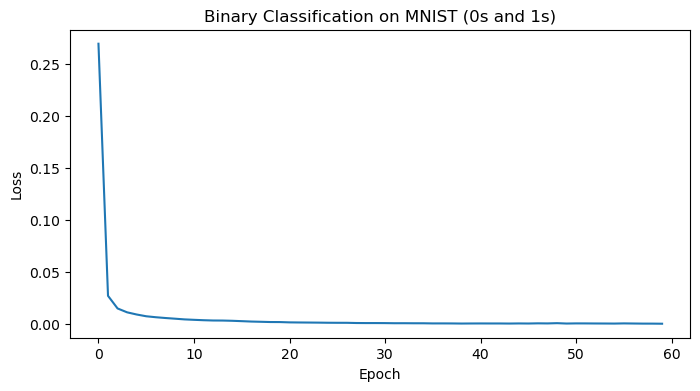

In [23]:
plt.figure(figsize=(8, 4))

plt.plot(np.arange(num_epochs), all_losses)
plt.title("Binary Classification on MNIST (0s and 1s)")
plt.xlabel("Epoch")
plt.ylabel("Loss")

Text(0.5, 1.0, 'Final L2 Weights')

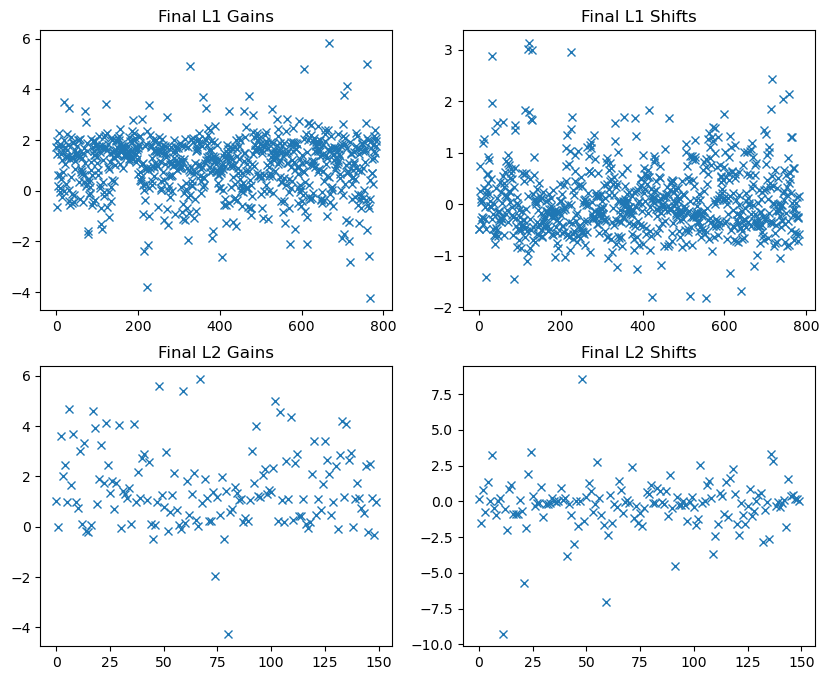

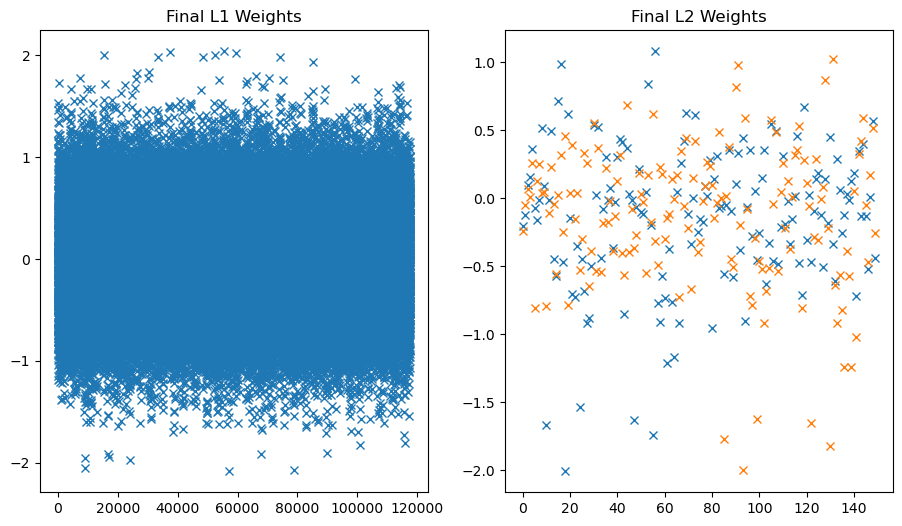

In [19]:
plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
plt.plot(MultiModel.L1_gains.detach().cpu(), 'x')
plt.title("Final L1 Gains")

plt.subplot(2,2,2)
plt.plot(MultiModel.L1_shifts.detach().cpu(), 'x')
plt.title("Final L1 Shifts")

plt.subplot(2,2,3)
plt.plot(MultiModel.L2_gains.detach().cpu(), 'x')
plt.title("Final L2 Gains")

plt.subplot(2,2,4)
plt.plot(MultiModel.L2_shifts.detach().cpu(), 'x')
plt.title("Final L2 Shifts")


plt.figure(figsize=(11,6))
plt.subplot(1,2,1)
plt.plot(MultiModel.L1_weights.detach().cpu().flatten(), 'x')
plt.title("Final L1 Weights")

plt.subplot(1,2,2)
plt.plot(MultiModel.L2_weights.detach().cpu()[0,:], 'x')
plt.plot(MultiModel.L2_weights.detach().cpu()[1,:], 'x')
#plt.plot(MultiModel.L2_weights.detach().cpu().flatten(), 'x')
plt.title("Final L2 Weights")

In [20]:
manual_gains_shifts = {}
manual_gains_shifts['L1_gains'] = MultiModel.L1_gains.detach().cpu().numpy()
manual_gains_shifts['L1_shifts'] = MultiModel.L1_shifts.detach().cpu().numpy()

manual_gains_shifts['L2_gains'] = MultiModel.L2_gains.detach().cpu().numpy()
manual_gains_shifts['L2_shifts'] = MultiModel.L2_shifts.detach().cpu().numpy()

manual_gains_shifts['L3_gains'] = MultiModel.L3_gains.detach().cpu().numpy()
manual_gains_shifts['L3_shifts'] = MultiModel.L3_shifts.detach().cpu().numpy()


MultiModel_transfer = SwinehartAbbottNetworkMultiLayer_ALT(L1_size, L2_size, L3_size, init_gain, init_shift, alpha, connect_prob=conProb, manual_gains_shifts=manual_gains_shifts).to(device)

with torch.no_grad():
    outputs = MultiModel_transfer(filtered_features_array.to(device))

    loss = loss_func(outputs, filtered_labels_array.view(-1,1).to(device))  # CrossEntropyLoss takes raw logits


print(f"Loss using just transfer to gains and shifts: {loss:.3f}")

Loss using just transfer to gains and shifts: 0.859


In [21]:
manual_weights = {}
manual_weights['L1_weights'] = MultiModel.L1_weights.detach().cpu().numpy()
manual_weights['L1_mask'] = MultiModel.L1_mask.detach().cpu().numpy()

manual_weights['L2_weights'] = MultiModel.L2_weights.detach().cpu().numpy()
manual_weights['L2_mask'] = MultiModel.L2_mask.detach().cpu().numpy()

MultiModel_transfer = SwinehartAbbottNetworkMultiLayer_ALT(L1_size, L2_size, L3_size, init_gain, init_shift, alpha, connect_prob=conProb, manual_weights=manual_weights).to(device)

with torch.no_grad():
    outputs = MultiModel_transfer(filtered_features_array.to(device))

    loss = loss_func(outputs, filtered_labels_array.view(-1,1).to(device))  # CrossEntropyLoss takes raw logits


print(f"Loss using just transfer to weights: {loss:.3f}")

Loss using just transfer to weights: 1.428
